In [11]:
# CELDA 1 - IMPORTS Y RUTAS

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image

# Ruta base del notebook: ml/notebooks/
# Subimos dos niveles para llegar a ml/ y de ahi a data/raw/train

NOTEBOOK_DIR = Path().resolve()
ML_DIR = NOTEBOOK_DIR.parent
RAW_TRAIN_DIR = ML_DIR / "data" / "raw" / "train"
RAW_TEST_DIR = ML_DIR / "data" / "raw" / "test"

# Verificamos

assert RAW_TRAIN_DIR.exists(), f"No encuentro train en: {RAW_TRAIN_DIR}"
assert RAW_TEST_DIR.exists(), f"No encuentro test en: {RAW_TEST_DIR}"

print(f"Train: {RAW_TRAIN_DIR}")
print(f"Test:  {RAW_TEST_DIR}")

Train: C:\Users\Juan\Desktop\sign-language-translator\ml\data\raw\train
Test:  C:\Users\Juan\Desktop\sign-language-translator\ml\data\raw\test


In [12]:
# CELDA 2 - CONTEO DE IMAGENES
# Cada subcarpeta dentro de train/ es una clase, queremos saber cuantas imagenes tiene cada una.
# Esto nos dira si el dataset esta balanceado o no.

clases = sorted(os.listdir(RAW_TRAIN_DIR))
conteo = {}

for clase in clases:
    carpeta = RAW_TRAIN_DIR / clase
    if carpeta.is_dir():
        conteo[clase] = len(list(carpeta.iterdir()))

df_conteo = pd.DataFrame(list(conteo.items()), columns=["clase", "num_imagenes"])
print(df_conteo.to_string(index=False))
print(f"\nTotal clases: {len(df_conteo)}")
print(f"Total imagenes: {df_conteo['num_imagenes'].sum()}")
print(f"Min por clase: {df_conteo['num_imagenes'].min()}")
print(f"Max por clase: {df_conteo['num_imagenes'].max()}")

  clase  num_imagenes
      A          3000
      B          3000
      C          3000
      D          3000
      E          3000
      F          3000
      G          3000
      H          3000
      I          3000
      J          3000
      K          3000
      L          3000
      M          3000
      N          3000
      O          3000
      P          3000
      Q          3000
      R          3000
      S          3000
      T          3000
      U          3000
      V          3000
      W          3000
      X          3000
      Y          3000
      Z          3000
    del          3000
nothing          3000
  space          3000

Total clases: 29
Total imagenes: 87000
Min por clase: 3000
Max por clase: 3000


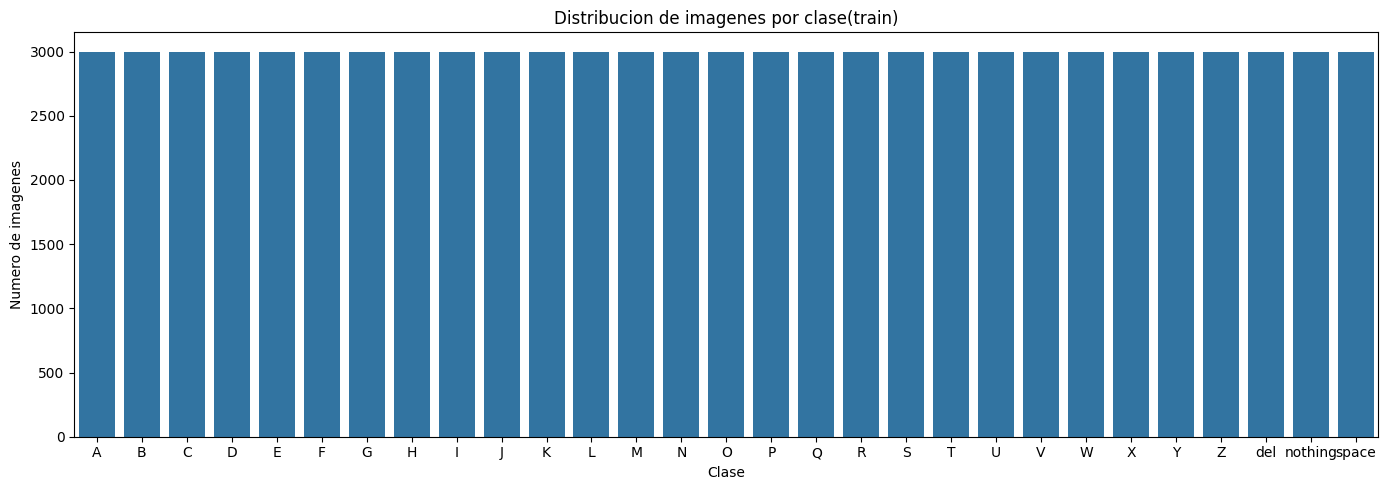

In [13]:
# CELDA 3 - GRAFICO DE DISTRIBUCION DE CLASES

plt.figure(figsize=(14, 5))
sns.barplot(data=df_conteo, x="clase", y="num_imagenes")
plt.title("Distribucion de imagenes por clase(train)")
plt.xlabel("Clase")
plt.ylabel("Numero de imagenes")
plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_distribucion_clases.png")
plt.show()

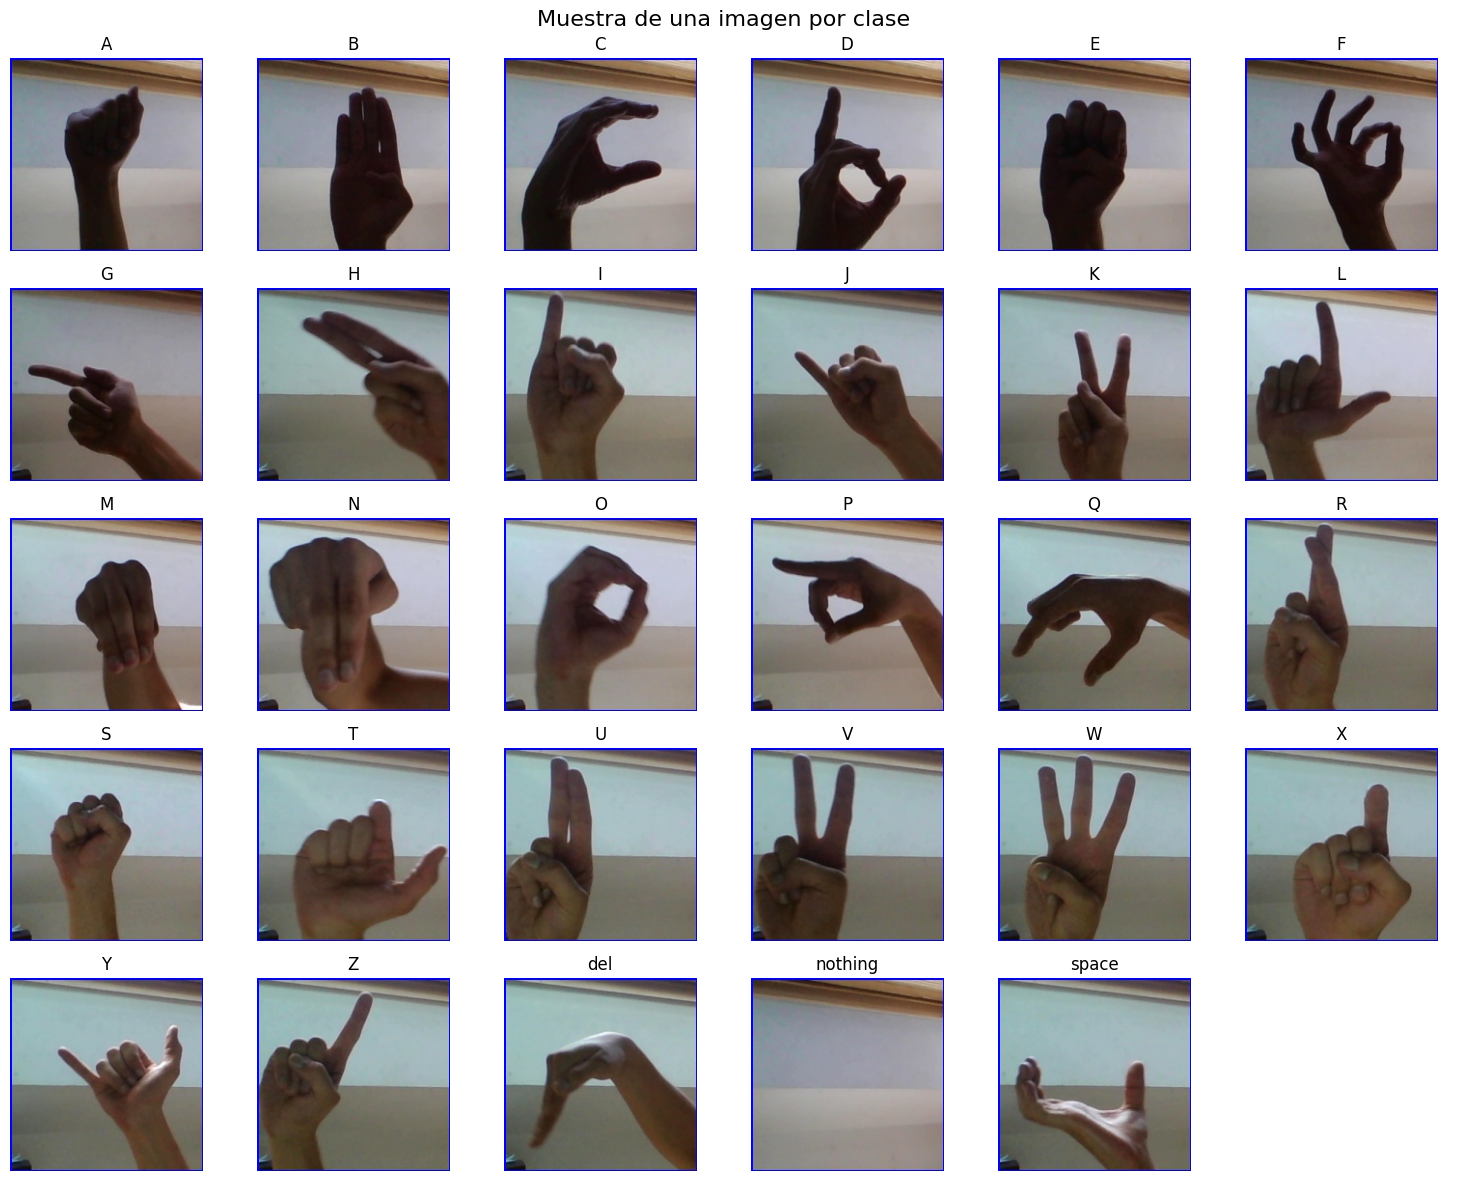

In [14]:
# CELDA 4 - MUESTRA IMAGENES POR CLASE

import cv2

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

for i, clase in enumerate(clases):
    carpeta = RAW_TRAIN_DIR / clase
    primera_imagen = list(carpeta.iterdir())[0]
    img = cv2.imread(str(primera_imagen))
    if img is None:
        print(f"ERROR leyendo clase {clase}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(clase)
    axes[i].axis("off")

axes[29].axis("off")

plt.suptitle("Muestra de una imagen por clase", fontsize=16)
plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_muestra_clases.png")
plt.show()

In [15]:
# CELDA 5 - RESOLUCION DE IMAGENES

resoluciones = {}

for clase in clases:
    carpeta  = RAW_TRAIN_DIR / clase
    primera_imagen = list(carpeta.iterdir())[0]
    img = cv2.imread(str(primera_imagen))
    h, w, c = img.shape
    resoluciones[clase] = (w, h)
    
df_res = pd.DataFrame(
    [(clase, w, h) for clase, (w, h) in resoluciones.items()], 
    columns=["clase", "ancho", "alto"]
)

print(df_res.to_string(index=False))
print(f"\nResoluciones unicas: {df_res[['ancho', 'alto']].drop_duplicates().values}")

  clase  ancho  alto
      A    200   200
      B    200   200
      C    200   200
      D    200   200
      E    200   200
      F    200   200
      G    200   200
      H    200   200
      I    200   200
      J    200   200
      K    200   200
      L    200   200
      M    200   200
      N    200   200
      O    200   200
      P    200   200
      Q    200   200
      R    200   200
      S    200   200
      T    200   200
      U    200   200
      V    200   200
      W    200   200
      X    200   200
      Y    200   200
      Z    200   200
    del    200   200
nothing    200   200
  space    200   200

Resoluciones unicas: [[200 200]]


In [16]:
# CELDA 6 - RESOLUCION TEST

imagenes_test = list(RAW_TEST_DIR.iterdir())
print(f"Total imagenes test: {len(imagenes_test)}")
print(f"Ejemplo de nombres: {[f.name for f in imagenes_test[:5]]}")

img = cv2.imread(str(imagenes_test[0]))
h, w, c = img.shape
print(f"Resolucion: {w}x{h}px")

Total imagenes test: 28
Ejemplo de nombres: ['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg']
Resolucion: 200x200px


In [17]:
# CELDA 7 - PRUEBA MEDIAPIPE

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

model_path = ML_DIR / "hand_landmarker.task"
if not model_path.exists():
    print("Descargando modelo...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task",
        str(model_path)
    )
    print("Descargado")
    
base_options = python.BaseOptions(model_asset_path=str(model_path))
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

# Probamos una imagen A
img_a = mp.Image.create_from_file(str(RAW_TRAIN_DIR / "A" / "A1.jpg"))
results_a = detector.detect(img_a)

print("=== Imagen A ===")
if results_a.hand_landmarks:
    landmarks = results_a.hand_landmarks[0]
    print(f"Landmarks detectados: {len(landmarks)}")
    print(f"Landmark 0 (muñeca): x={landmarks[0].x:.4f}, y={landmarks[0].y:.4f}, z={landmarks[0].z:.4f}")
else:
    print("No se detecto mano")

# Probamos con nothing
img_nothing = mp.Image.create_from_file(str(RAW_TRAIN_DIR / "nothing" / "nothing1.jpg"))
results_nothing = detector.detect(img_nothing)

print("\n=== Imagen nothing ===")
if results_nothing.hand_landmarks:
    print(f"Landmarks detectados: {len(results_nothing.hand_landmarks[0].landmark)}")
else:
    print("No se detecto mano")

=== Imagen A ===
Landmarks detectados: 21
Landmark 0 (muñeca): x=0.4420, y=0.5801, z=-0.0000

=== Imagen nothing ===
No se detecto mano


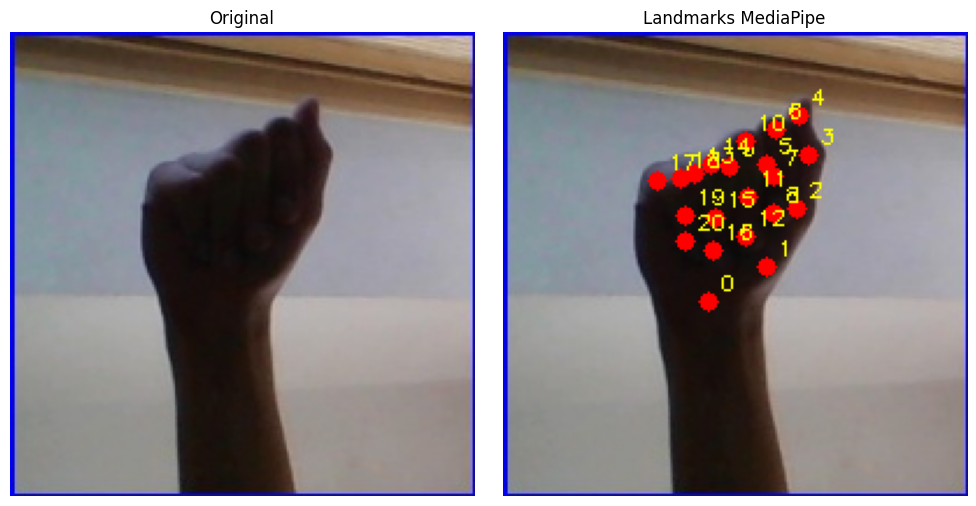

In [18]:
# CELDA 8 - VISUALIZACION DE LANDMARKS SOBRE IMAGEN

img_a_original = cv2.imread(str(RAW_TRAIN_DIR / "A" / "A1.jpg"))
img_a_rgb = cv2.cvtColor(img_a_original, cv2.COLOR_BGR2RGB)

results = detector.detect(mp.Image.create_from_file(str(RAW_TRAIN_DIR / "A" / "A1.jpg")))
landmarks = results.hand_landmarks[0]

h, w = img_a_rgb.shape[:2]

# Dibujar landmarks
img_con_landmarks = img_a_rgb.copy()
for i, lm in enumerate(landmarks):
    cx, cy = int(lm.x * w), int(lm.y * h)
    cv2.circle(img_con_landmarks, (cx, cy), 4, (255, 0, 0), -1)
    cv2.putText(img_con_landmarks, str(i), (cx + 5, cy -5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3,(255, 255, 0), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_a_rgb)
ax1.set_title("Original")
ax1.axis("off")
ax2.imshow(img_con_landmarks)
ax2.set_title("Landmarks MediaPipe")
ax2.axis("off")

plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_landmarks.png")
plt.show()

In [19]:
# CELDA 9 - TASA DE DETECCION POR CLASE

MUESTRA_POR_CLASE = 100
resultados_deteccion = {}

for clase in clases:
    carpeta = RAW_TRAIN_DIR / clase
    imagenes = list(carpeta.iterdir())[:MUESTRA_POR_CLASE]
    detectadas = 0
    
    for img_path in imagenes:
        img = mp.Image.create_from_file(str(img_path))
        result = detector.detect(img)
        if result.hand_landmarks:
            detectadas += 1
    tasa = detectadas / len(imagenes) * 100
    resultados_deteccion[clase] = tasa
    print(f"{clase}: {tasa:.1f}%")
    
print(f"\nMedia general (sin nothing): {sum(v for k,v in resultados_deteccion.items() if k != 'nothing') / 28:.1f}%")

A: 91.0%
B: 91.0%
C: 97.0%
D: 98.0%
E: 96.0%
F: 99.0%
G: 91.0%
H: 94.0%
I: 100.0%
J: 97.0%
K: 100.0%
L: 98.0%
M: 35.0%
N: 11.0%
O: 100.0%
P: 99.0%
Q: 99.0%
R: 99.0%
S: 100.0%
T: 91.0%
U: 86.0%
V: 89.0%
W: 84.0%
X: 89.0%
Y: 100.0%
Z: 98.0%
del: 67.0%
nothing: 0.0%
space: 88.0%

Media general (sin nothing): 88.8%


C:\Users\Juan\AppData\Local\Temp\ipykernel_7028\4205493703.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_deteccion, x="clase", y="tasa_deteccion", palette=colores)


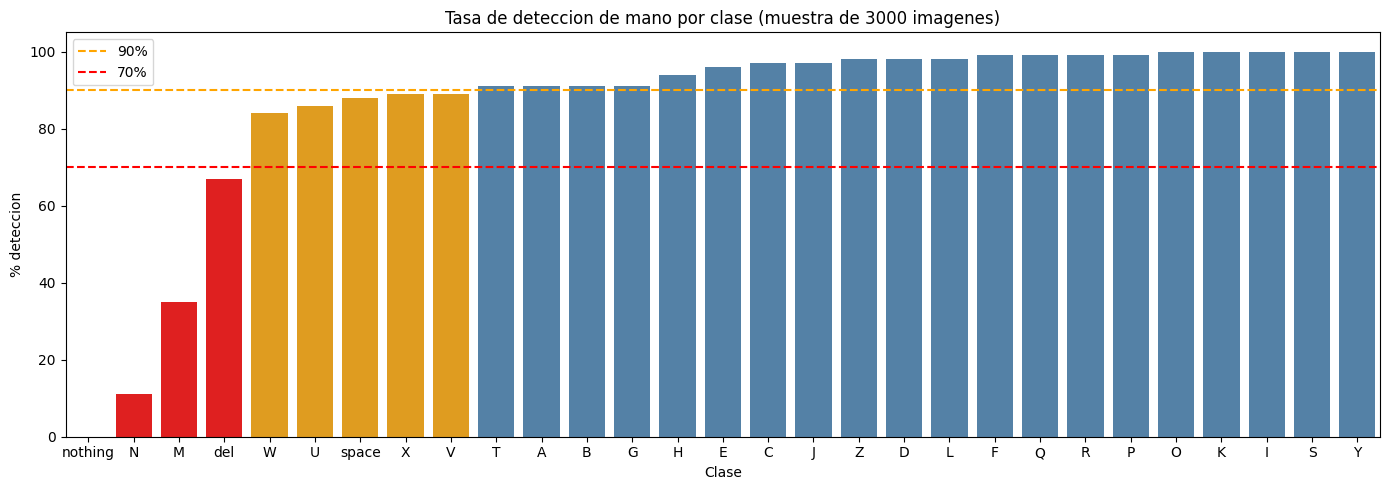

In [20]:
# CELDA 10 - GRAFICO TASA DE DETECCION

df_deteccion = pd.DataFrame(
    list(resultados_deteccion.items()),
    columns=["clase", "tasa_deteccion"]
).sort_values("tasa_deteccion")

plt.figure(figsize=(14, 5))
colores = ["red" if t < 70 else "orange" if t < 90 else "steelblue"
           for t in df_deteccion["tasa_deteccion"]]
sns.barplot(data=df_deteccion, x="clase", y="tasa_deteccion", palette=colores)
plt.axhline(y=90, color="orange", linestyle="--", label="90%")
plt.axhline(y=70, color="red", linestyle="--", label="70%")
plt.title("Tasa de deteccion de mano por clase (muestra de 3000 imagenes)")
plt.xlabel("Clase")
plt.ylabel("% deteccion")
plt.legend()
plt.tight_layout()
plt.savefig(ML_DIR / "data" / "img" / "eda_tasa_deteccion3000.png")
plt.show()

In [21]:
# Probar umbral mas bajo para M y N
base_options_low = python.BaseOptions(model_asset_path=str(model_path))
options_low = vision.HandLandmarkerOptions(
    base_options=base_options_low,
    num_hands=1,
    min_hand_detection_confidence=0.2,
    min_hand_presence_confidence=0.2
)
detector_low = vision.HandLandmarker.create_from_options(options_low)

for clase in ["M", "N", "del"]:
    carpeta = RAW_TRAIN_DIR / clase
    imagenes = list(carpeta.iterdir())[:100]
    detectadas = 0
    for img_path in imagenes:
        img = mp.Image.create_from_file(str(img_path))
        result = detector_low.detect(img)
        if result.hand_landmarks:
            detectadas += 1
    print(f"{clase}: {detectadas}%")

M: 57%
N: 24%
del: 89%


In [22]:
# CELDA 11 - DETECCION DE IMAGENES CORRUPTAS

import concurrent.futures
import os

def check_image(img_path):
    """
    Intenta abrir la imagen y convertirla a array numpy.
    Devuelve (path, error_type, detail) donde error_type es:
    - None          -> imagen valida
    - 'open_error'  -> PIL no puede abrir/descodificar el archivo.
    - 'empty_array' -> abre pero el array es todo ceros (datos incoherentes)
    - 'wrong_space' -> dimensiones inesperadas (no es 200x200 o no tiene canales)
    """
    try:
        with Image.open(img_path) as img:
            img_array = np.array(img.convert('RGB'))
            
        # Dato incoherente, array completamente vacio
        if img_array.max() == 0:
            return (img_path, 'empty_array', 'max_value=0')
        
        # Forma inesperada (el dataset deberia ser todo 200x200x3)
        if img_array.shape != (200, 200, 3):
           return (img_path, 'wrong_shape', str(img_array.shape))
        
        return (img_path, None, None)
    
    except Exception as e:
        return (img_path,'open error', str(e))
    
print("\n" + "="*60)
print("\nCELDA 11 - DETECCION DE IMAGENES CORRUPTAS")
print("="*60)
    
# Recopilar todas las rutas de train y test
    
all_paths = []
for split_name, split_dir in [('train', RAW_TRAIN_DIR), ('test', RAW_TEST_DIR)]:    
    if split_dir.exists():
        for class_dir in sorted(split_dir.iterdir()):
             if class_dir.is_dir():
                for img_file in class_dir.iterdir():
                     if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                         all_paths.append((img_file, split_name, class_dir.name))

print(f"Total de imagenes a analizar: {len(all_paths):,}")

# Procesamiento paralelo

corrupt_images = []
n_workers = os.cpu_count() or 4

with concurrent.futures.ThreadPoolExecutor (max_workers=n_workers) as executor:
    futures = {
        executor.submit(check_image, path): (path, split, cls)
        for path, split, cls in all_paths
    }
    for i, future in enumerate(concurrent.futures.as_completed(futures)):
        if i % 5000 == 0:
            print(f"    Progreso : {i}:, / {len(all_paths):,} imagenes analizadas")
        path, split, cls = futures[future]
        img_path, error_type, detail = future.result()
        if error_type is not None:
            corrupt_images.append({
                'path': str(img_path),
                'split': split,
                'class': cls,
                'error_type': error_type,
                'detail': detail
            })

# Resultados

print(f"\nImagenes analizadas: {len(all_paths):,}")
print(f"Imagenes corruptas: {len(corrupt_images)}")

if len(corrupt_images) == 0:
    print("\nDataset integro. No se encontraron imagenes corruptas")
else:
    df_corrupt = pd.DataFrame(corrupt_images)
    
    print("\n— Desglose por tipo de error:")
    print(df_corrupt['error_type'].value_counts().to_string())

    print("\n— Distribución por clase:")
    print(df_corrupt.groupby(['split', 'class'])['error_type']
          .count().sort_values(ascending=False).to_string())

    print("\n— Listado completo:")
    print(df_corrupt.to_string(index=False))

    corrupt_csv = ML_DIR / "data" / "processed" / "corrupt_images.csv"
    corrupt_csv.parent.mkdir(parents=True, exist_ok=True)
    df_corrupt.to_csv(corrupt_csv, index=False)
    print(f"\nGuardado en: {corrupt_csv}")
    



CELDA 11 - DETECCION DE IMAGENES CORRUPTAS
Total de imagenes a analizar: 87,000
    Progreso : 0:, / 87,000 imagenes analizadas
    Progreso : 5000:, / 87,000 imagenes analizadas
    Progreso : 10000:, / 87,000 imagenes analizadas
    Progreso : 15000:, / 87,000 imagenes analizadas
    Progreso : 20000:, / 87,000 imagenes analizadas
    Progreso : 25000:, / 87,000 imagenes analizadas
    Progreso : 30000:, / 87,000 imagenes analizadas
    Progreso : 35000:, / 87,000 imagenes analizadas
    Progreso : 40000:, / 87,000 imagenes analizadas
    Progreso : 45000:, / 87,000 imagenes analizadas
    Progreso : 50000:, / 87,000 imagenes analizadas
    Progreso : 55000:, / 87,000 imagenes analizadas
    Progreso : 60000:, / 87,000 imagenes analizadas
    Progreso : 65000:, / 87,000 imagenes analizadas
    Progreso : 70000:, / 87,000 imagenes analizadas
    Progreso : 75000:, / 87,000 imagenes analizadas
    Progreso : 80000:, / 87,000 imagenes analizadas
    Progreso : 85000:, / 87,000 imagene


PUNTO 8 - VARIABILIDAD DEL BRILLO DE CADA CLASE
Calculando brillo de 87,000 imagenes...

- Estadistica de brillo por clase (ordenado de mas oscuro a mas brillante):
         brillo_medio  desv_std  minimo  maximo
class                                          
G              117.18     26.11   73.28  158.75
H              121.23     21.21   70.93  155.05
del            123.90     20.47   75.24  158.57
F              125.38     20.09   85.74  162.15
N              125.41     21.88   76.92  158.49
A              125.93     20.68   80.19  161.78
X              126.34     20.22   71.39  157.72
I              126.40     18.76   78.05  156.28
J              126.61     21.71   73.96  156.36
E              126.88     21.20   80.38  163.93
B              128.34     19.91   87.93  160.55
P              129.57     23.05   74.07  157.98
T              129.68     20.32   84.92  165.25
V              130.42     19.95   89.92  165.06
M              130.86     20.36   77.54  160.90
Q              130

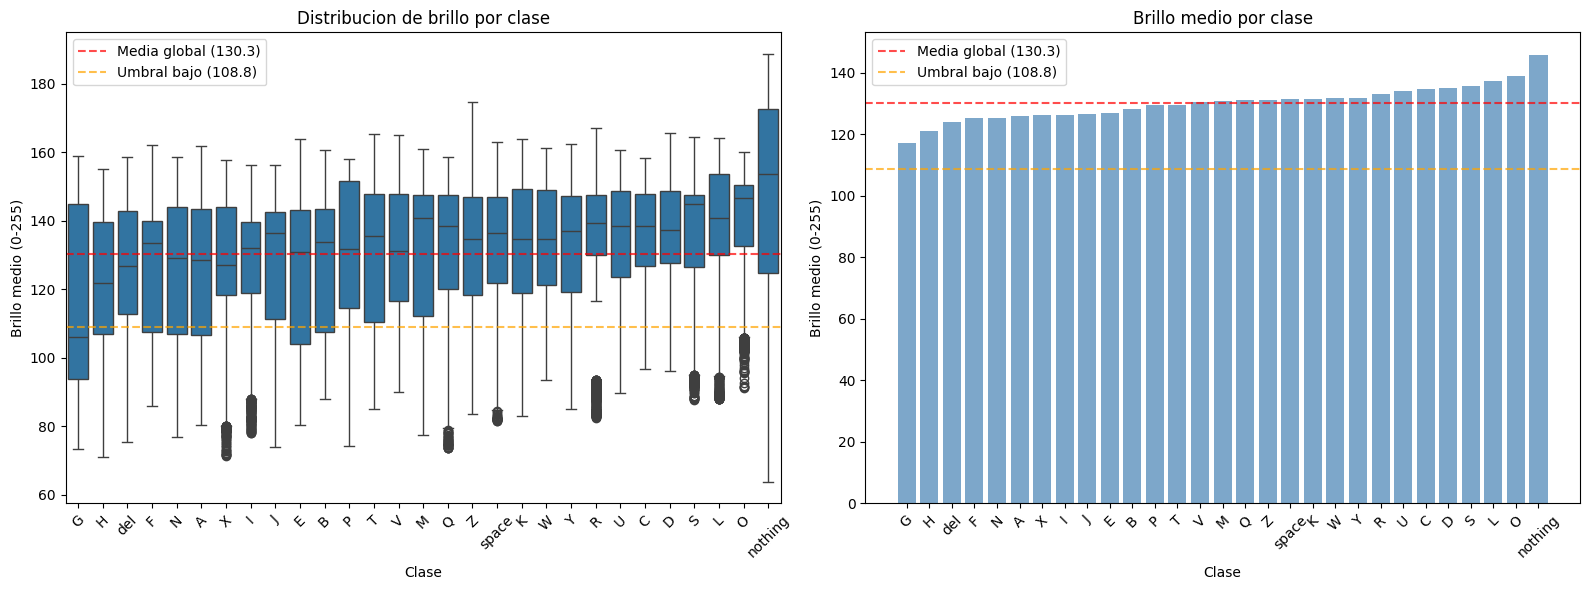


Media global de brillo: 130.26
Desviación estándar global: 21.43


In [23]:
# CELDA 12 - VARIABILIDAD DEL BRILLO DENTRO DE CADA CLASE

def get_brightness(img_path):
    """ Devuelve el brillo medio de una imagen (media de los 3 canales RGB)"""
    try:
        with Image.open(img_path) as img:
            return np.mean(np.array(img.convert('RGB')))
    except Exception:
        return None

print("\n" + "="*60)
print("PUNTO 8 - VARIABILIDAD DEL BRILLO DE CADA CLASE")
print("="*60)

# Recopilar brillo de todas las imagenes de train
brightness_data = []
n_workers = os.cpu_count() or 4

all_train_paths = [
    (img_file, class_dir.name)
    for class_dir in sorted(RAW_TRAIN_DIR.iterdir()) if class_dir.is_dir()
    for img_file in class_dir.iterdir() if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']
]

print(f"Calculando brillo de {len(all_train_paths):,} imagenes...")

with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as executor:
    futures = {
        executor.submit(get_brightness, path): (path, cls)
        for path, cls in all_train_paths
    }
    for future in concurrent.futures.as_completed(futures):
        path, cls = futures[future]
        brightness = future.result()
        if brightness is not None:
            brightness_data.append({'class': cls, 'brightness': brightness})
            
df_brightness = pd.DataFrame(brightness_data)

# Estadisticas por clase
stats = df_brightness.groupby('class')['brightness'].agg(['mean', 'std', 'min', 'max'])
stats.columns = ['brillo_medio', 'desv_std', 'minimo', 'maximo']
stats = stats.sort_values('brillo_medio')

print("\n- Estadistica de brillo por clase (ordenado de mas oscuro a mas brillante):")
print(stats.round(2).to_string())

# Clases con brillo medio bajo (umbral: por debajo de la media global - 1 std)
global_mean = df_brightness['brightness'].mean()
global_std = df_brightness['brightness'].std()
umbral_bajo = global_mean - global_std

clases_oscuras = stats[stats['brillo_medio'] < umbral_bajo]
if not clases_oscuras.empty:
    print(f"\nClases con brillo medio bajo (< {umbral_bajo:.1f}):")
    print(clases_oscuras.round(2).to_string())
else:
    print(f"\nNinguna clase con brillo sistematicamente bajo (umbral: {umbral_bajo:.1f})")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: distribucion de brillo por clase 
df_brightness_sorted = df_brightness.copy()
order = stats.sort_values('brillo_medio').index.tolist()
sns.boxplot(data=df_brightness, x='class', y='brightness', order=order, ax=axes[0])
axes[0].set_title('Distribucion de brillo por clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Brillo medio (0-255)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=global_mean, color='red', linestyle='--', alpha=0.7, label=f'Media global ({global_mean:.1f})')
axes[0].axhline(y=umbral_bajo, color='orange', linestyle='--', alpha=0.7, label=f'Umbral bajo ({umbral_bajo:.1f})')
axes[0].legend()

# Barplot: brillo medio por clase
axes[1].bar(stats.index, stats['brillo_medio'], color='steelblue', alpha=0.7)
axes[1].axhline(y=global_mean, color='red', linestyle='--', alpha=0.7, label=f'Media global ({global_mean:.1f})')
axes[1].axhline(y=umbral_bajo, color='orange', linestyle='--', alpha=0.7, label=f'Umbral bajo ({umbral_bajo:.1f})')
axes[1].set_title('Brillo medio por clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Brillo medio (0-255)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMedia global de brillo: {global_mean:.2f}")
print(f"Desviación estándar global: {global_std:.2f}")


CELDA 13 - VERIFICACION DE LA DIVISION TRAIN/TEST
Total imagenes: 87,000
Semilla aleatoria: 42

Train: 69,600 imagenes (80.0%)
Test: 17,400 imagenes (20.0%)

- Distribucion por clase:
         train  test  train_%  test_%
A         2400   600     3.45    3.45
B         2400   600     3.45    3.45
C         2400   600     3.45    3.45
D         2400   600     3.45    3.45
E         2400   600     3.45    3.45
F         2400   600     3.45    3.45
G         2400   600     3.45    3.45
H         2400   600     3.45    3.45
I         2400   600     3.45    3.45
J         2400   600     3.45    3.45
K         2400   600     3.45    3.45
L         2400   600     3.45    3.45
M         2400   600     3.45    3.45
N         2400   600     3.45    3.45
O         2400   600     3.45    3.45
P         2400   600     3.45    3.45
Q         2400   600     3.45    3.45
R         2400   600     3.45    3.45
S         2400   600     3.45    3.45
T         2400   600     3.45    3.45
U         2400   

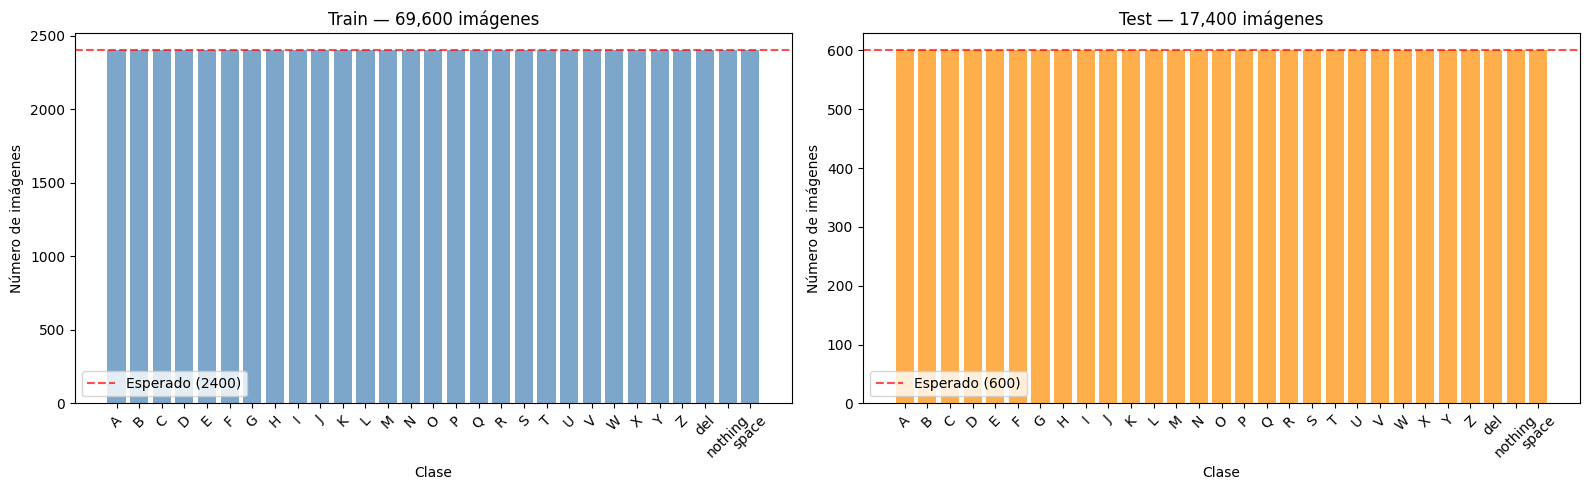


NOTA: La división real se realizará en extract_landmarks.py
usando train_test_split con random_state=42 y stratify=labels.
Este análisis confirma que la estratificación mantiene el balance.


In [24]:
# CELDA 13 - VERIFICACION DE LA DIVISION TRAIN/TEST

from sklearn.model_selection import train_test_split

print("\n" + "="*60)
print("CELDA 13 - VERIFICACION DE LA DIVISION TRAIN/TEST")
print("="*60)

RANDOM_SEED = 42

# Recopilar paths y etiquetas de train
all_paths = []
all_labels = []
for class_dir in sorted(RAW_TRAIN_DIR.iterdir()):
    if class_dir.is_dir():
        for img_file in class_dir.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                all_paths.append(img_file)
                all_labels.append(class_dir.name)

print(f"Total imagenes: {len(all_paths):,}")
print(f"Semilla aleatoria: {RANDOM_SEED}")

# Division estratificada 
paths_train, paths_test, labels_train, labels_test = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=all_labels
)

print(f"\nTrain: {len(paths_train):,} imagenes ({len(paths_train)/len(all_paths)*100:.1f}%)")
print(f"Test: {len(paths_test):,} imagenes ({len(paths_test)/len(all_paths)*100:.1f}%)")

# Verificar balance por clase
df_train_dist = pd.Series(labels_train).value_counts().sort_index()
df_test_dist = pd.Series(labels_test).value_counts().sort_index()

df_split = pd.DataFrame({
    'train': df_train_dist,
    'test': df_test_dist
})
df_split['train_%'] = (df_split['train'] / df_split['train'].sum() * 100).round(2)
df_split['test_%'] = (df_split['test'] / df_split['test'].sum() * 100).round(2)

print("\n- Distribucion por clase:")
print(df_split.to_string())

# Verificar que ninguna clase se desvia mas de +-1 imagen del esperado
expected_train = int(3000 * 0.8) # 2400
expected_test = int(3000 * 0.2) # 600

desviaciones = df_split[
    (df_split['train'] != expected_train) | (df_split['test'] != expected_test)
]
if desviaciones.empty:
    print(f"\nBalance perfecto: todas las clases tienen exactamente {expected_train} en train y {expected_test} en test")
else:
    print(f"\nClases con desviacion respecto a lo esperado ({expected_train} / {expected_test}):")
    print(desviaciones.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot train
axes[0].bar(df_split.index, df_split['train'], color='steelblue', alpha=0.7)
axes[0].axhline(y=expected_train, color='red', linestyle='--', alpha=0.7, label=f'Esperado ({expected_train})')
axes[0].set_title(f'Train — {len(paths_train):,} imágenes')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de imágenes')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Barplot test
axes[1].bar(df_split.index, df_split['test'], color='darkorange', alpha=0.7)
axes[1].axhline(y=expected_test, color='red', linestyle='--', alpha=0.7, label=f'Esperado ({expected_test})')
axes[1].set_title(f'Test — {len(paths_test):,} imágenes')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Número de imágenes')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nNOTA: La división real se realizará en extract_landmarks.py")
print(f"usando train_test_split con random_state={RANDOM_SEED} y stratify=labels.")
print(f"Este análisis confirma que la estratificación mantiene el balance.")

In [25]:
# Test M y N

for letra, nombre in [("M", "test2_M.jpg"), ("N", "test2_N.jpg")]:
    img = mp.Image.create_from_file(str(ML_DIR / "data" / "test" / nombre))
    result = detector.detect(img)
    if result.hand_landmarks:
        print(f"{letra}: Detectada - {len(result.hand_landmarks[0])} landmarks")
    else:
        print(f"{letra}: No detectada")

M: Detectada - 21 landmarks
N: Detectada - 21 landmarks


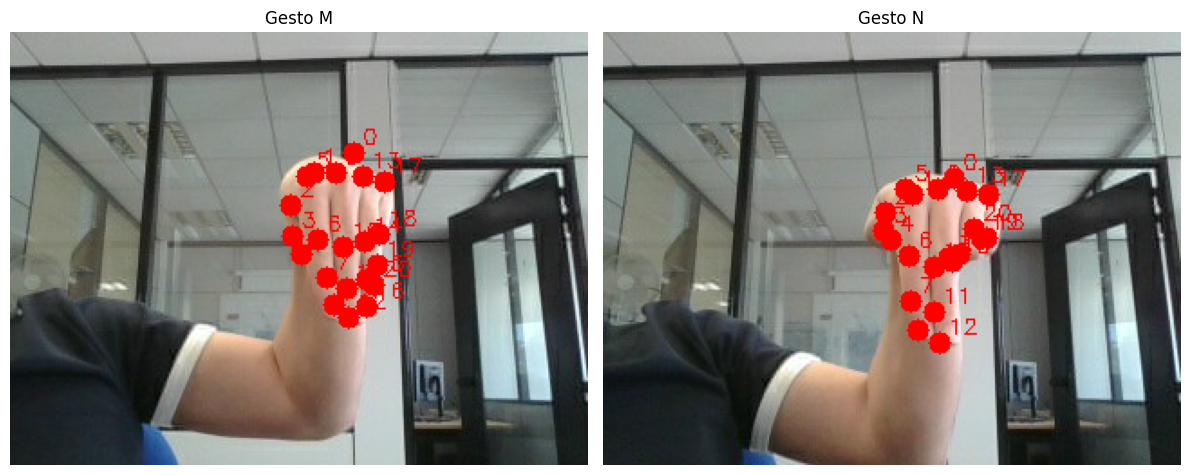

In [26]:
# Test M y N con imagen

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, (letra, nombre) in enumerate([("M", "test2_M.jpg"), ("N", "test2_N.jpg")]):
    img_cv = cv2.imread(str(ML_DIR / "data" / "test" / nombre))
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    
    result = detector.detect(mp.Image.create_from_file(str(ML_DIR / "data" / "test" / nombre)))
    landmarks = result.hand_landmarks[0]
    
    h, w = img_rgb.shape[:2]
    img_landmarks = img_rgb.copy()
    for j, lm in enumerate(landmarks):
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img_landmarks, (cx, cy), 6, (255, 0, 0), -1)
        cv2.putText(img_landmarks, str(j), (cx + 5, cy -5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    axes[i].imshow(img_landmarks)
    axes[i].set_title(f"Gesto {letra}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(ML_DIR / "data" / "test" / "eda_landmarks_M_N_2.png")
plt.show()